# Synthetic Options on the MSCI ACWI

**Objective:** price and quote options on the iShares MSCI ACWI ETF in the absence of a liquid options market on the index.

**Methodology:**
1. **Data.** Daily closes from 2018-02-24 to 2024-02-24 are downloaded from Yahoo Finance for the ACWI ETF and 10 ETFs representing the countries with the largest weights in the index. Returns and volatilities are computed on **adjusted** closes (dividends are not risk); pricing uses **traded** (unadjusted) prices, which are the terms in which the strikes are quoted.
2. **Replicating regression.** OLS of ACWI log returns on the ETFs' log returns; all ten ETFs are individually significant, so the trim is for parsimony, not significance: the intercept (p = 0.40) and the three smallest legs (INDA, EWC, EWT, each under 4% of the basket) are dropped, then backward VIF elimination removes EWQ (the largest VIF, a near-duplicate of EWG with ρ = 0.95), leaving a 6-ETF basket (R² = 0.993 vs 0.994 with all ten) that defines the **synthetic ACWI**. The model assumptions are validated and a \$1M portfolio in the ACWI is compared against the synthetic one.
3. **Market parameters as of the valuation date (2023-02-24).** A single USD risk-free rate for all the ETFs (they are USD-denominated assets), taken from the 1-year Treasury (FRED DGS1) on that date; each ETF's dividend yield as the average of the previous 5 years (total return vs price return, which smooths extraordinary distributions); two volatility estimates computable *on that date*: historical (5 years) and EWMA (RiskMetrics, λ=0.94).
4. **Pricing.** Three options are quoted with Black-Scholes with dividends: a 9m call struck at \$85, a 9m digital call struck at \$87 and a 12m call spread struck at \$78/\$100. Replicating each one as a linear combination of options on the basket ETFs, with strikes that preserve the moneyness ($K_i = S_i \cdot K/S_{ACWI}$), and tracking their daily mark-to-market. For convex payoffs the basket of options **super-replicates** the option on the basket (imperfect correlations make it worth more); that premium is quantified by comparing against the option priced directly on the synthetic index, and the implied volatility embedded in the quote is extracted.
5. **Validation.** Stability of the regression weights on a rolling window; a daily delta-hedging backtest (each option is sold at the quoted premium and hedged with the synthetic underlying until expiry, reporting the P&L); and a Monte Carlo of the hedging error over simulated paths.

## Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from scipy.optimize import brentq
from scipy.stats import norm

%matplotlib inline

## Data and log returns

`data` (adjusted closes) for returns, regression and volatilities; `prices` (traded closes) for strikes and pricing.

In [2]:
start_date, end_date = '2018-02-24', '2024-02-24'
tickers = ['IVV', 'EWJ', 'EWU', 'MCHI', 'EWC', 'EWQ', 'EWG', 'EWL', 'INDA', 'EWT']

raw = yf.download(['ACWI'] + tickers, start=start_date, end=end_date, auto_adjust=False)
data = raw['Adj Close'][['ACWI'] + tickers]
prices = raw['Close'][['ACWI'] + tickers]

# every fund distributes over this window, so total return must beat price return;
# otherwise Yahoo served closes with the dividend adjustment missing, re-run this cell
assert ((data.iloc[-1] / data.iloc[0]) > (prices.iloc[-1] / prices.iloc[0])).all(), 'dividend adjustment missing'

returns = np.log(data / data.shift(1)).dropna()
data.tail()

[                       0%                       ]

[*********             18%                       ]  2 of 11 completed

[*************         27%                       ]  3 of 11 completed

[*****************     36%                       ]  4 of 11 completed

[**********************45%                       ]  5 of 11 completed

...

[**********************73%**********             ]  8 of 11 completed

[**********************82%**************         ]  9 of 11 completed

[**********************91%*******************    ]  10 of 11 completed

[*********************100%***********************]  11 of 11 completed

Ticker,ACWI,IVV,EWJ,EWU,MCHI,EWC,EWQ,EWG,EWL,INDA,EWT
Date,,,,,,,,,,,
2024-02-16,101.062332,486.301361,62.863758,29.763834,36.828735,35.141842,36.039490,27.778183,44.092209,50.832245,42.675423
2024-02-20,100.774101,483.598358,63.142632,29.927773,36.524918,35.007717,36.399055,27.844074,44.611832,51.189659,42.990234
2024-02-21,100.802925,484.034332,63.012482,29.736511,37.293957,34.959816,36.611107,27.966444,44.715759,50.812389,42.582832
2024-02-22,102.541901,494.148895,64.044266,29.955091,37.759190,35.295135,37.044430,28.427692,44.517357,51.358437,43.221714
2024-02-23,102.580330,494.429810,64.146523,30.064386,37.882614,35.438843,37.191944,28.446516,44.772442,51.427933,42.971718


## Linear regression

In [3]:
y = returns['ACWI']
X = sm.add_constant(returns[tickers])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ACWI   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 2.705e+04
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:42:35   Log-Likelihood:                 8434.2
No. Observations:                1508   AIC:                        -1.685e+04
Df Residuals:                    1497   BIC:                        -1.679e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.987e-05   2.34e-05     -0.850      0.3

Only the intercept fails the significance test (p = 0.40); every ETF is individually significant (smallest |t| ≈ 6.8), so significance gives no reason to trim the basket. For parsimony, each name kept is one more leg to trade in every option quote and hedge below. The intercept and the three smallest coefficients in the table above (INDA, EWC, EWT, each under 4% of the basket) are dropped. The surviving legs are then screened for redundancy with variance inflation factors:

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X.drop(columns=['INDA', 'EWC', 'EWT', 'const'])
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
          index=X.columns, name='VIF').round(1)

IVV      4.0
EWJ      3.0
EWU      6.0
MCHI     1.5
EWQ     13.8
EWG     11.0
EWL      4.5
Name: VIF, dtype: float64

EWQ and EWG breach the usual VIF ≈ 10 bar: they are near-duplicates (ρ = 0.95, see the correlation matrix further down), so one leg is enough. Standard backward elimination removes the largest VIF (EWQ) after which every remaining VIF falls below 10 (checked in the residual analysis) and R² holds at 0.993.

In [5]:
X = X.drop(columns=['EWQ'])
final_model = sm.OLS(y, X).fit(cov_type='HC3')
print(final_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   ACWI   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                              9205.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):                        0.00
Time:                        12:42:35   Log-Likelihood:                          8241.4
No. Observations:                1508   AIC:                                 -1.647e+04
Df Residuals:                    1502   BIC:                                 -1.644e+04
Df Model:                           6                                                  
Covariance Type:                  HC3                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

### Why the ETF and not the index as the target?

The MSCI ACWI index (`data/IndexMSCI.csv`) is computed from each regional market's close, while every ETF in the basket closes at the same time on NYSE. That timing mismatch misaligns the daily returns and hurts the regression R² without the basket replicating any worse. The replication target is therefore the ACWI ETF: it shares the basket's closing time and is also the underlying in whose terms the strikes are quoted.

In [6]:
msci_index = pd.read_csv('data/IndexMSCI.csv', encoding='utf-8-sig', parse_dates=['Date'], index_col='Date')
r_index = np.log(msci_index / msci_index.shift(1)).dropna()['MSCI ACWI Index']
common = returns.index.intersection(r_index.index)
index_model = sm.OLS(r_index.loc[common], returns.loc[common, X.columns]).fit()

print(f'R² replicating the MSCI index (regional closes): {index_model.rsquared:.3f}')
print(f'R² replicating the ACWI ETF (NYSE close):        {final_model.rsquared:.3f}')

R² replicating the MSCI index (regional closes): 0.945
R² replicating the ACWI ETF (NYSE close):        0.993


### Coefficient stability

The regression is re-estimated on a 2-year rolling window (504 trading days). The weights move gradually and with no regime changes, which makes replicating with static weights over the valuation period defensible.

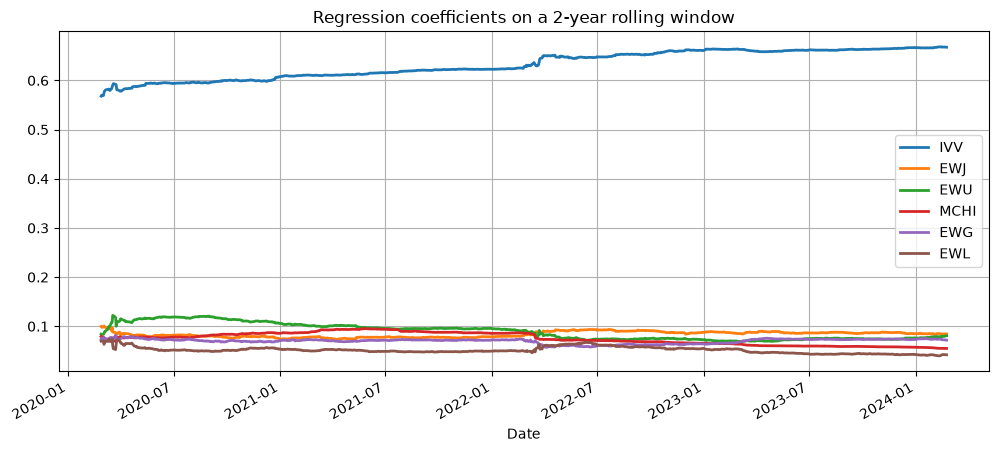

,IVV,EWJ,EWU,MCHI,EWG,EWL
Date,,,,,,
2020-02-27,0.568,0.100,0.084,0.079,0.074,0.070
2024-02-23,0.667,0.084,0.081,0.055,0.072,0.042


In [7]:
from statsmodels.regression.rolling import RollingOLS

betas = RollingOLS(y, X, window=504).fit().params.dropna()
betas.plot(figsize=(12, 5), linewidth=2, title='Regression coefficients on a 2-year rolling window')
plt.grid(True)
plt.show()
betas.iloc[[0, -1]].round(3)

## Residual analysis

No VIF exceeds the ≈ 10 bar after the screen; the surviving European legs still co-move, which widens their individual confidence intervals but not the joint fit. The basket is only ever traded as a whole, never interpreted coefficient by coefficient.

In [8]:
# Multicollinearity
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
          index=X.columns, name='VIF').round(2)

IVV     3.99
EWJ     2.99
EWU     5.12
MCHI    1.54
EWG     6.00
EWL     4.35
Name: VIF, dtype: float64

In [9]:
# Residual normality
from scipy.stats import shapiro

stat, p_value = shapiro(final_model.resid)
print(f'Shapiro-Wilk Test statistic: {stat}, p-value: {p_value}')

Shapiro-Wilk Test statistic: 0.9364187372541195, p-value: 7.013629478822521e-25


**Normality: rejected** (W = 0.94, p ≈ 10⁻²⁴), as for virtually any daily equity return series, the residuals inherit the fat tails visible in the QQ plot below. This threatens neither the weights nor their z-tests: OLS point estimates do not need normal errors, and with n = 1508 the central limit theorem keeps the HC3 inference valid. Only exact small-sample confidence intervals would suffer.

In [10]:
# Zero mean of residuals
from scipy.stats import ttest_1samp

t_test_result = ttest_1samp(final_model.resid, 0)
print(f't-statistic: {t_test_result.statistic}, p-value: {t_test_result.pvalue}')

t-statistic: 0.01851814065265888, p-value: 0.9852279572331266


**Zero mean: not rejected** (t ≈ 0.02, p ≈ 0.99). Not automatic in a model without an intercept, nothing forces the residuals to center, so this is real evidence that the basket carries no systematic daily drift against the ACWI; compounded over six years, it is why the \$1M curves finish together.

In [11]:
# Residual autocorrelation
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(final_model.resid)
print(f'Durbin-Watson statistic: {dw_stat}')

Durbin-Watson statistic: 2.4992707630973556


**Autocorrelation: mild and negative** (DW ≈ 2.50; 2 means none, so ρ₁ ≈ −0.25). The typical signature of daily closes bouncing around fair value (closing-auction and bid–ask noise that partly reverses the next day). It does not bias the weights, and for hedging it is benign: consecutive replication errors tend to offset rather than accumulate.

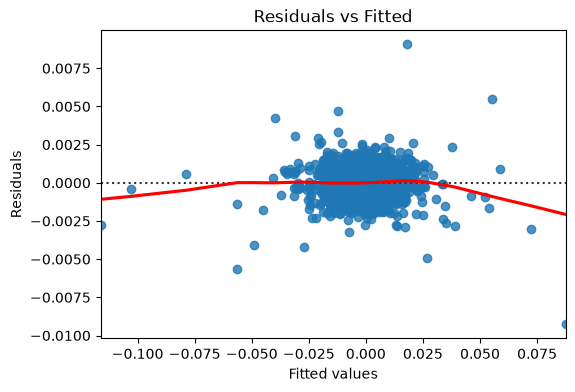

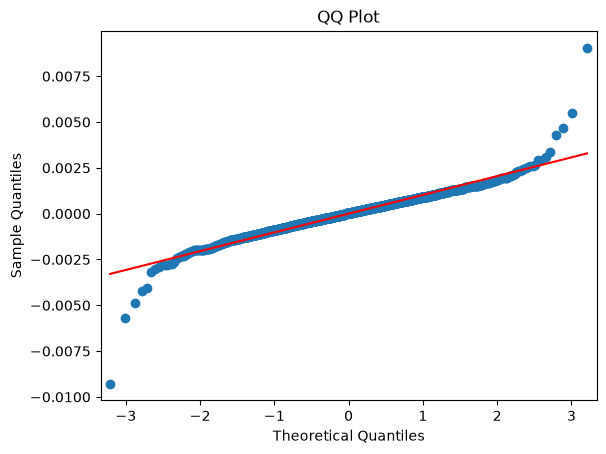

In [12]:
# Residuals vs Fitted
plt.figure(figsize=(6, 4))
sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# QQ Plot
sm.qqplot(final_model.resid, line='s')
plt.title('QQ Plot')
plt.show()

**Residuals vs fitted:** the lowess line stays flat at zero across the whole range, no missed curvature, so the linear specification is adequate.

**QQ plot:** both tails leave the line, the same fat tails Shapiro–Wilk flags, extreme joint moves are larger than a Gaussian would produce, while the center is well behaved.

## Correlation matrix

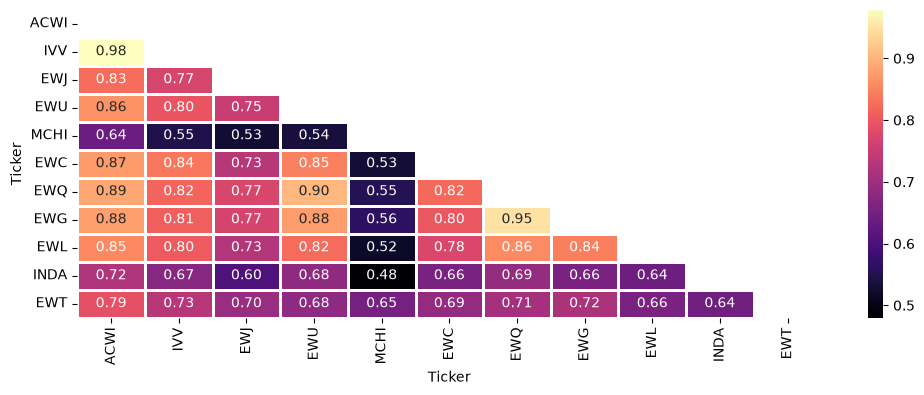

Ticker
ACWI    1.000000
IVV     0.978839
EWJ     0.826750
EWU     0.864466
MCHI    0.638207
EWC     0.873726
EWQ     0.885558
EWG     0.877606
EWL     0.854931
INDA    0.722434
EWT     0.790051
Name: ACWI, dtype: float64


In [13]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(corr, annot=True, cmap='magma', fmt='.2f', linewidths=1, mask=np.triu(corr))
plt.xticks(rotation=90)
plt.setp(plt.gca().get_xticklabels(), ha='center')
plt.show()
print(corr['ACWI'])

## \$1,000,000 portfolio, 2018-02-24 to 2024-02-24

In [14]:
components = list(X.columns)
weights = final_model.params / final_model.params.sum()
print(weights.round(4))

data['ACWI_synthetic'] = data[components].dot(weights)
prices['ACWI_synthetic'] = prices[components].dot(weights)
returns['ACWI_synthetic'] = returns[components].dot(weights)

portfolio = 1_000_000 * np.exp(returns[['ACWI', 'ACWI_synthetic']].cumsum())
portfolio.tail(5).map('${:,.2f}'.format)

IVV     0.6363
EWJ     0.0869
EWU     0.0862
MCHI    0.0661
EWG     0.0740
EWL     0.0506
dtype: float64


Ticker,ACWI,ACWI_synthetic
Date,,
2024-02-16,"$1,579,128.78","$1,575,192.95"
2024-02-20,"$1,574,625.08","$1,571,310.58"
2024-02-21,"$1,575,075.47","$1,573,920.85"
2024-02-22,"$1,602,247.47","$1,600,915.63"
2024-02-23,"$1,602,847.94","$1,603,106.75"


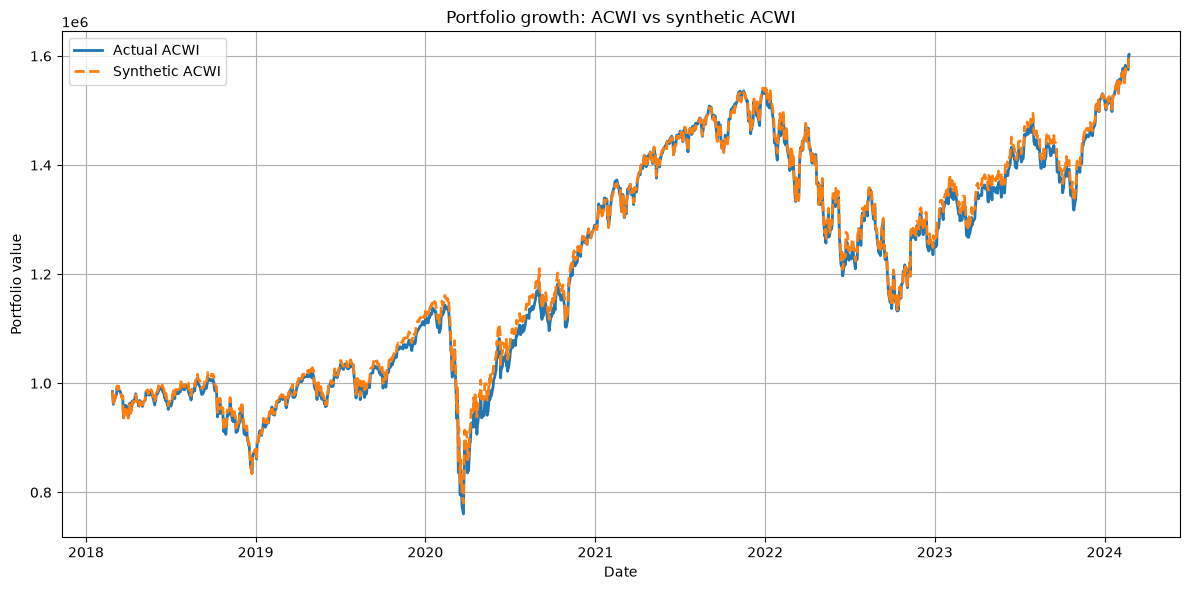

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio.index, portfolio['ACWI'], label='Actual ACWI', linewidth=2)
plt.plot(portfolio.index, portfolio['ACWI_synthetic'], label='Synthetic ACWI', linewidth=2, linestyle='--')
plt.title('Portfolio growth: ACWI vs synthetic ACWI')
plt.xlabel('Date')
plt.ylabel('Portfolio value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Market parameters as of the valuation date

Everything is estimated with information available on **2023-02-24**:
- **Risk-free rate:** the ETFs are USD assets listed on NYSE, so everything is discounted with a single USD rate: the 1-year Treasury (FRED, series DGS1) at the valuation-date close, a maturity in line with the 9- and 12-month expiries.
- **Dividend yield** of each ETF: average of the previous 5 years, estimated as the log difference between total return (adjusted prices) and price return. Averaging smooths extraordinary, non-recurring distributions that would distort a short trailing estimate (e.g. EWT, in the 10-ETF universe, paid a Dec-2022 special distribution that alone would push its 12-month yield to ~17%).
- **Volatility:** 5-year historical and EWMA (RiskMetrics, λ=0.94), which weights the recent past more heavily; both annualized.

In [16]:
valuation_date = '2023-02-24'

r_usd = float(pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS1'
                          f'&cosd={valuation_date}&coed={valuation_date}', index_col=0).iloc[0, 0]) / 100
print(f'USD risk-free rate (1-year Treasury, FRED DGS1, as of {valuation_date}): {r_usd:.2%}')

T_sample = (pd.Timestamp(valuation_date) - data.index[0]).days / 365.25
total_return = data.loc[valuation_date, components] / data.iloc[0][components]
price_return = prices.loc[valuation_date, components] / prices.iloc[0][components]
div = np.log(total_return / price_return) / T_sample

prior_returns = returns.loc[:valuation_date]
vol_hist = prior_returns.std() * np.sqrt(252)
vol_ewma = np.sqrt((prior_returns**2).ewm(alpha=0.06).mean().iloc[-1] * 252)  # RiskMetrics λ=0.94

pd.DataFrame({'historical vol': vol_hist[components + ['ACWI_synthetic']],
              'EWMA vol': vol_ewma[components + ['ACWI_synthetic']],
              'dividend yield': div}).map(lambda v: '-' if pd.isna(v) else f'{v:.2%}')

USD risk-free rate (1-year Treasury, FRED DGS1, as of 2023-02-24): 5.05%


,historical vol,EWMA vol,dividend yield
Ticker,,,
ACWI_synthetic,20.41%,14.62%,-
EWG,24.68%,18.75%,2.58%
EWJ,18.06%,14.74%,1.61%
EWL,18.77%,14.27%,2.00%
EWU,22.10%,11.87%,3.82%
IVV,21.88%,16.60%,1.81%
MCHI,29.97%,28.11%,1.42%


## Adjusted strikes

The strikes (\$85, \$87, \$78, \$100) are in ACWI-ETF terms; each index keeps the same moneyness: $K_i = S_i \cdot K / S_{ACWI}$, using traded prices.

In [17]:
S_A = prices.loc[valuation_date, 'ACWI']
print(f'ACWI on {valuation_date}: ${S_A:.2f}')

# The synthetic index is a value-weighted basket (~$268), not on the ACWI price scale. Rescale it
# to the ACWI share so every quote comes out in ACWI-ETF terms. Proportional payoffs (call, spread)
# then scale by the same factor; the digital's fixed $1 payoff and all deltas do not (see price_series).
scale = S_A / prices.loc[valuation_date, 'ACWI_synthetic']
prices['ACWI_synthetic'] *= scale

cols = components + ['ACWI_synthetic']
strikes = pd.DataFrame({K: prices.loc[valuation_date, cols] * (K / S_A) for K in [85, 87, 78, 100]})
strikes.round(2)

ACWI on 2023-02-24: $88.16


,85,87,78,100
Ticker,,,,
IVV,383.84,392.87,352.23,451.58
EWJ,53.63,54.89,49.21,63.09
EWU,31.09,31.83,28.53,36.58
MCHI,46.05,47.13,42.26,54.17
EWG,26.07,26.68,23.92,30.67
EWL,42.16,43.15,38.69,49.60
ACWI_synthetic,85.00,87.00,78.00,100.00


## Black-Scholes with dividends

Call: $C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$, $\Delta = e^{-qT} N(d_1)$.

Digital call (cash-or-nothing paying \$1): $C = e^{-rT} N(d_2)$, $\Delta = e^{-rT}\,\varphi(d_2)/(S\sigma\sqrt{T})$.

Call spread: $C = C(K_1) - C(K_2)$, $\Delta = \Delta(K_1) - \Delta(K_2)$.

With $d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$.


In [18]:
def bs_d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)

def call(S, K, T, r, q, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def call_delta(S, K, T, r, q, sigma):
    return np.exp(-q * T) * norm.cdf(bs_d1_d2(S, K, T, r, q, sigma)[0])

def digital(S, K, T, r, q, sigma):
    return np.exp(-r * T) * norm.cdf(bs_d1_d2(S, K, T, r, q, sigma)[1])

def digital_delta(S, K, T, r, q, sigma):
    d2 = bs_d1_d2(S, K, T, r, q, sigma)[1]
    return np.exp(-r * T) * norm.pdf(d2) / (S * sigma * np.sqrt(T))

def price_series(fn, K, T_init, sigma, until, agg_scale=1.0):
    """Daily series of fn for each component and the synthetic, from the valuation date to `until`.
    agg_scale expresses the aggregated basket in ACWI-share terms: `scale` (=S_A/S_syn) for prices
    of proportional payoffs, 1 for deltas and the digital's fixed $1 payoff, 1/scale for the digital's
    delta (a per-price sensitivity). Per-component columns stay in their own (traded-price) terms."""
    S = prices.loc[valuation_date:until, components]
    T = T_init - (S.index - S.index[0]).days / 365
    S, T = S[T > 0], T[T > 0]
    out = pd.DataFrame(fn(S.values, strikes.loc[components, K].values, np.asarray(T)[:, None],
                          r_usd, div[components].values, sigma[components].values),
                       index=S.index, columns=components)
    out['ACWI_synthetic'] = out[components].dot(weights) * agg_scale
    return out

# minimal self-checks
assert abs(call(100, 80, 1, 0.0, 0.0, 1e-9) - 20) < 1e-4               # no vol, rate or dividend: intrinsic value
assert call(100, 100, 1, 0.03, 0.02, 0.2) < call(100, 100, 1, 0.03, 0.0, 0.2)  # dividends make the call cheaper
assert abs(digital(100, 80, 1, 0.0, 0.0, 1e-9) - 1) < 1e-6             # deep-ITM digital pays ~1
assert 0 < digital(100, 100, 1, 0.02, 0.0, 0.2) < np.exp(-0.02)

## 9-month call, strike \$85

In [19]:
call85_hist = price_series(call, 85, 0.75, vol_hist, '2023-11-24', scale)
call85_ewma = price_series(call, 85, 0.75, vol_ewma, '2023-11-24', scale)
delta85_hist = price_series(call_delta, 85, 0.75, vol_hist, '2023-11-24')

summary = pd.DataFrame({'price (hist vol)': call85_hist.iloc[0].round(2),
                        'price (EWMA vol)': call85_ewma.iloc[0].round(2),
                        'delta % (hist vol)': (delta85_hist.iloc[0] * 100).round(2)})
print(f'As of {valuation_date}:')
summary

As of 2023-02-24:


,price (hist vol),price (EWMA vol),delta % (hist vol)
IVV,41.82,35.35,65.23
EWJ,5.24,4.69,67.49
EWU,3.10,2.08,61.32
MCHI,6.33,6.05,63.94
EWG,2.98,2.47,62.98
EWL,4.13,3.54,66.24
ACWI_synthetic,9.26,7.83,64.89


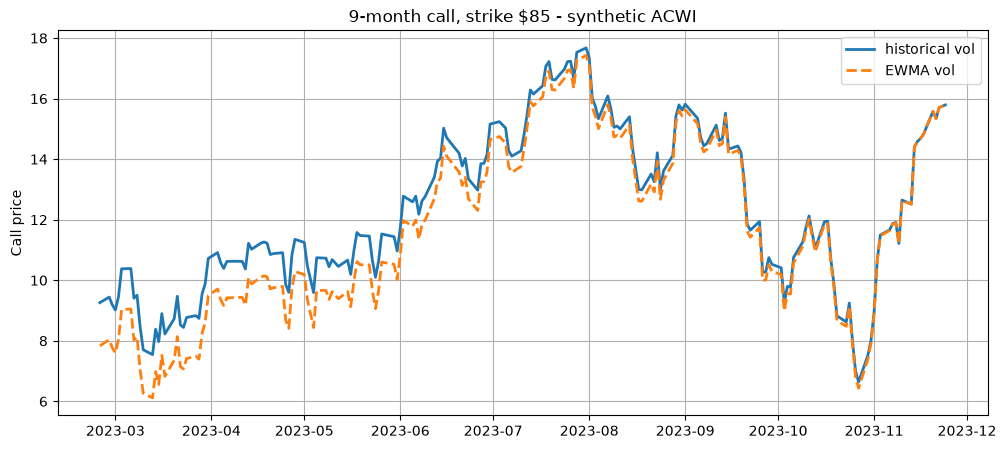

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(call85_hist.index, call85_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(call85_ewma.index, call85_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('9-month call, strike $85 - synthetic ACWI')
plt.ylabel('Call price')
plt.legend()
plt.grid(True)
plt.show()

## 9-month digital call, strike \$87

In [21]:
digital87_hist = price_series(digital, 87, 0.75, vol_hist, '2023-11-24')
digital87_ewma = price_series(digital, 87, 0.75, vol_ewma, '2023-11-24')
deltadigital87_hist = price_series(digital_delta, 87, 0.75, vol_hist, '2023-11-24', 1 / scale)

summary = pd.DataFrame({'price (hist vol)': digital87_hist.iloc[0].round(3),
                        'price (EWMA vol)': digital87_ewma.iloc[0].round(3),
                        'delta % (hist vol)': (deltadigital87_hist.iloc[0] * 100).round(2)})
print(f'As of {valuation_date}:')
summary

As of 2023-02-24:


,price (hist vol),price (EWMA vol),delta % (hist vol)
IVV,0.521,0.554,0.51
EWJ,0.547,0.573,4.35
EWU,0.490,0.545,6.22
MCHI,0.491,0.498,3.10
EWG,0.497,0.525,6.64
EWL,0.535,0.569,5.35
ACWI_synthetic,0.518,0.550,6.71


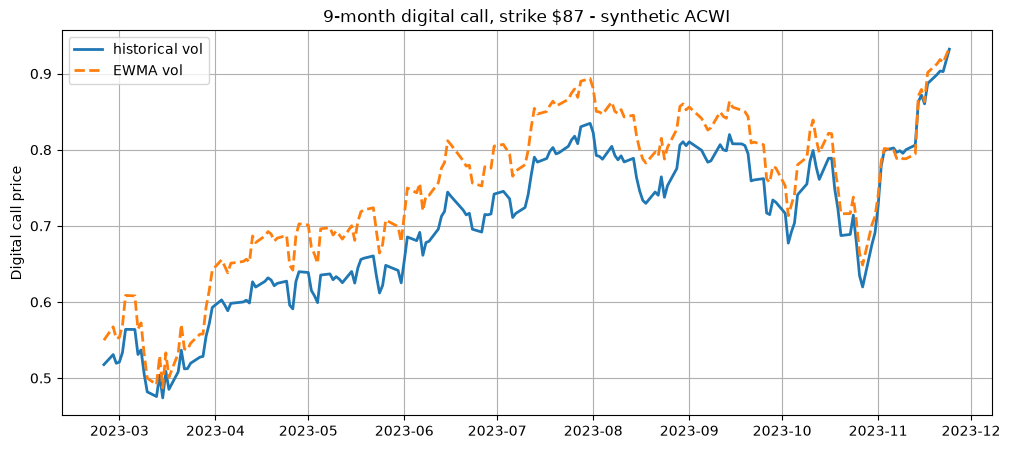

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(digital87_hist.index, digital87_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(digital87_ewma.index, digital87_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('9-month digital call, strike $87 - synthetic ACWI')
plt.ylabel('Digital call price')
plt.legend()
plt.grid(True)
plt.show()

## 12-month call spread, strikes \$78 and \$100

In [23]:
spread_hist = price_series(call, 78, 1.0, vol_hist, '2024-02-24', scale) - price_series(call, 100, 1.0, vol_hist, '2024-02-24', scale)
spread_ewma = price_series(call, 78, 1.0, vol_ewma, '2024-02-24', scale) - price_series(call, 100, 1.0, vol_ewma, '2024-02-24', scale)
deltaspread_hist = price_series(call_delta, 78, 1.0, vol_hist, '2024-02-24') - price_series(call_delta, 100, 1.0, vol_hist, '2024-02-24')

summary = pd.DataFrame({'price (hist vol)': spread_hist.iloc[0].round(2),
                        'price (EWMA vol)': spread_ewma.iloc[0].round(2),
                        'delta % (hist vol)': (deltaspread_hist.iloc[0] * 100).round(2)})
print(f'As of {valuation_date}:')
summary

As of 2023-02-24:


,price (hist vol),price (EWMA vol),delta % (hist vol)
IVV,47.47,49.62,41.05
EWJ,6.89,7.12,48.50
EWU,3.57,3.78,40.54
MCHI,5.44,5.51,30.67
EWG,3.08,3.21,36.76
EWL,5.31,5.53,46.97
ACWI_synthetic,10.50,10.97,40.95


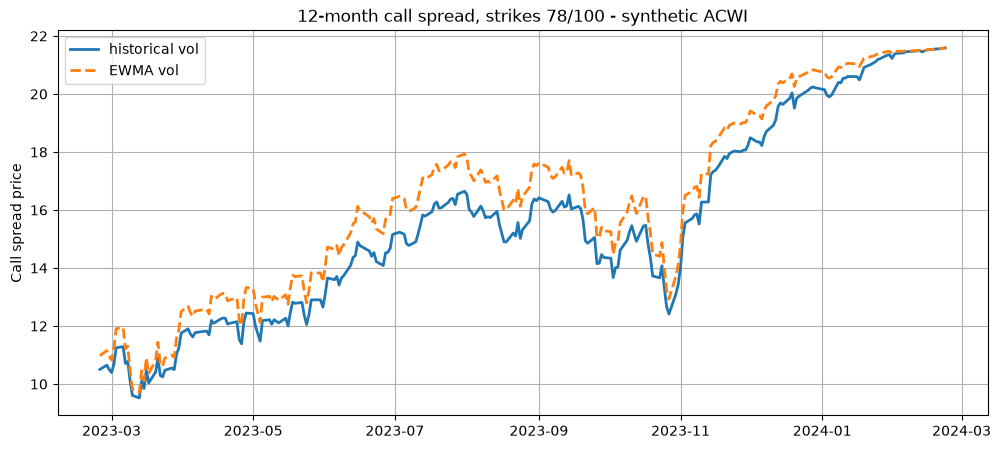

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(spread_hist.index, spread_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(spread_ewma.index, spread_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('12-month call spread, strikes $78/$100 - synthetic ACWI')
plt.ylabel('Call spread price')
plt.legend()
plt.grid(True)
plt.show()

## Basket of options vs option on the basket

A linear combination of options is not an option on the linear combination. For convex payoffs (the call), Jensen's inequality and imperfect correlations imply that the basket of calls is worth more than the call on the synthetic index: it is a **super-replication** (whoever sells the ACWI call and buys the basket ends up over-hedged), and the difference is the correlation premium. For non-convex payoffs (the digital and the capped spread) the inequality does not apply and the sign can flip, as the table shows.

To quantify it, each option is priced directly on the synthetic index, with its own volatility and dividend yield, and the implied volatility is extracted from the basket quote.

In [25]:
S_syn = prices.loc[valuation_date, 'ACWI_synthetic']
basket_value = (weights * prices.loc[valuation_date, components]).sum()  # scale-free denominator for the yield
q_syn = (weights * prices.loc[valuation_date, components] * div[components]).sum() / basket_value
v_syn = vol_hist['ACWI_synthetic']
K85s, K87s, K78s, K100s = strikes.loc['ACWI_synthetic', [85, 87, 78, 100]]
print(f'Synthetic S = ${S_syn:.2f}, synthetic q = {q_syn:.2%}, historical vol = {v_syn:.2%}')

comparison = pd.DataFrame({
    'basket of options (quote)': [call85_hist.iloc[0]['ACWI_synthetic'],
                                  digital87_hist.iloc[0]['ACWI_synthetic'],
                                  spread_hist.iloc[0]['ACWI_synthetic']],
    'option on the basket': [call(S_syn, K85s, 0.75, r_usd, q_syn, v_syn),
                             digital(S_syn, K87s, 0.75, r_usd, q_syn, v_syn),
                             call(S_syn, K78s, 1.0, r_usd, q_syn, v_syn) - call(S_syn, K100s, 1.0, r_usd, q_syn, v_syn)],
}, index=['Call $85 (9m)', 'Digital call $87 (9m)', 'Call spread $78/$100 (12m)'])
comparison['correlation premium'] = comparison.iloc[:, 0] - comparison.iloc[:, 1]
comparison.round(3)

Synthetic S = $88.16, synthetic q = 1.83%, historical vol = 20.41%


,basket of options (quote),option on the basket,correlation premium
Call $85 (9m),9.260,8.850,0.410
Digital call $87 (9m),0.518,0.529,-0.011
Call spread $78/$100 (12m),10.504,10.626,-0.122


In [26]:
C_basket = call85_hist.iloc[0]['ACWI_synthetic']
implied_vol_syn = brentq(lambda s: call(S_syn, K85s, 0.75, r_usd, q_syn, s) - C_basket, 1e-4, 3.0)
print(f'Implied volatility of the synthetic call quote: {implied_vol_syn:.2%}')
print(f'Historical volatility of the synthetic index:   {v_syn:.2%}')

Implied volatility of the synthetic call quote: 21.91%
Historical volatility of the synthetic index:   20.41%


## Delta-hedging backtest

Validation of the quotes: each option is sold at the basket premium (historical vol) and delta-hedged daily with the synthetic underlying until expiry. Cash accrues at the USD rate and the position in the underlying earns its dividend yield. A small P&L relative to the premium indicates that the quote and its deltas are consistent with the realized path; products with concentrated gamma (the digital near the strike) show a larger hedging error, which is why in practice they are quoted with an extra margin or replicated with a call spread.

In [27]:
def hedge_backtest(premium, delta_fn, payoff, T_init, until):
    S = prices.loc[valuation_date:until, 'ACWI_synthetic']
    T = np.maximum(T_init - (S.index - S.index[0]).days / 365, 1e-9)
    delta = delta_fn(S.values, T)
    cash = premium - delta[0] * S.iloc[0]
    for i in range(1, len(S)):
        dt = T[i - 1] - T[i]
        cash = cash * np.exp(r_usd * dt) + delta[i - 1] * S.iloc[i - 1] * q_syn * dt
        cash -= (delta[i] - delta[i - 1]) * S.iloc[i]
    pnl = delta[-1] * S.iloc[-1] + cash - payoff(S.iloc[-1])
    return {'premium received': premium, 'final S': S.iloc[-1], 'payoff paid': payoff(S.iloc[-1]),
            'hedging P&L': pnl, 'P&L % of premium': pnl / premium * 100}

results = pd.DataFrame({
    'Call $85 (9m)': hedge_backtest(
        call85_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: call_delta(s, K85s, t, r_usd, q_syn, v_syn),
        lambda s: max(s - K85s, 0), 0.75, '2023-11-24'),
    'Digital call $87 (9m)': hedge_backtest(
        digital87_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: digital_delta(s, K87s, t, r_usd, q_syn, v_syn),
        lambda s: float(s > K87s), 0.75, '2023-11-24'),
    'Call spread $78/$100 (12m)': hedge_backtest(
        spread_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: call_delta(s, K78s, t, r_usd, q_syn, v_syn) - call_delta(s, K100s, t, r_usd, q_syn, v_syn),
        lambda s: np.clip(s - K78s, 0, K100s - K78s), 1.0, '2024-02-24'),
}).T
results.round(3)

,premium received,final S,payoff paid,hedging P&L,P&L % of premium
Call $85 (9m),9.260,100.734,15.734,1.723,18.611
Digital call $87 (9m),0.518,100.734,1.000,-0.186,-35.899
Call spread $78/$100 (12m),10.504,111.997,22.000,-3.009,-28.650


## Monte Carlo of the hedging error

The backtest above is a single realized path. To assess the quote in general, GBM paths of the synthetic index are simulated and the daily delta hedge of the 9m call sold at the quoted premium (historical vol) is repeated under two realized-volatility scenarios: **equal to the quoted vol** (validates the hedging machinery: mean P&L ≈ 0, the dispersion is the discrete-rebalancing error) and **equal to the EWMA** (if recent volatility persists, the positive mean P&L is the margin implicit in quoting with the historical vol).

In [28]:
def mc_hedge(K, T0, sigma_quote, sigma_realized, n_sims=5000, seed=42):
    """P&L (% of premium) from selling the call at sigma_quote and hedging daily, over GBM at sigma_realized."""
    rng = np.random.default_rng(seed)
    m = round(T0 * 252)
    dt = T0 / m
    steps = (r_usd - q_syn - sigma_realized**2 / 2) * dt + sigma_realized * np.sqrt(dt) * rng.standard_normal((m, n_sims))
    S = S_syn * np.exp(np.vstack([np.zeros(n_sims), np.cumsum(steps, axis=0)]))
    T = T0 - np.arange(m)[:, None] * dt
    delta = call_delta(S[:-1], K, T, r_usd, q_syn, sigma_quote)

    premium = call(S_syn, K, T0, r_usd, q_syn, sigma_quote)
    cash = premium - delta[0] * S[0]
    for i in range(1, m):
        cash = cash * np.exp(r_usd * dt) + delta[i - 1] * S[i - 1] * q_syn * dt
        cash -= (delta[i] - delta[i - 1]) * S[i]
    cash = cash * np.exp(r_usd * dt) + delta[-1] * S[-2] * q_syn * dt
    pnl = delta[-1] * S[-1] + cash - np.maximum(S[-1] - K, 0)
    return pnl / premium * 100

scenarios = pd.DataFrame({
    f'realized σ = quoted σ ({v_syn:.1%})': mc_hedge(K85s, 0.75, v_syn, v_syn),
    f'realized σ = EWMA ({vol_ewma["ACWI_synthetic"]:.1%})': mc_hedge(K85s, 0.75, v_syn, vol_ewma['ACWI_synthetic']),
})
scenarios.describe(percentiles=[0.05, 0.5, 0.95]).round(2)

,realized σ = quoted σ (20.4%),realized σ = EWMA (14.6%)
count,5000.00,5000.00
mean,0.00,18.18
std,4.23,7.06
min,-22.43,1.87
5%,-6.88,7.36
50%,-0.02,17.91
95%,6.94,30.13
max,20.74,40.18


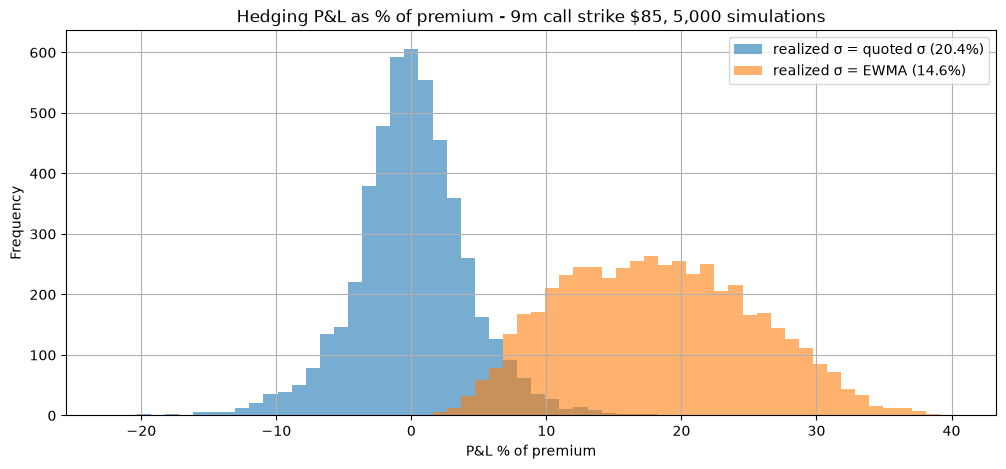

In [29]:
scenarios.plot.hist(bins=60, alpha=0.6, figsize=(12, 5),
                    title='Hedging P&L as % of premium - 9m call strike $85, 5,000 simulations')
plt.xlabel('P&L % of premium')
plt.grid(True)
plt.show()